# **`Process for getting CM`**

In [4]:
!pip install nilearn
import nilearn as nl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 75.0 MB/s eta 0:00:00


**Checking if anat and fmri preprop data are good to create time series**

In [5]:
from nilearn import plotting, image
#checking dimensions of data - if 4, there's time series
subjects = [2,8,13,27,31,36,48,49,51,65,78,83,85,96,150,206]
for subject in subjects:
  str_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_bold.nii"
  nl.EXPAND_PATH_WILDCARDS = False
  fmri_obj = image.load_img(str_img)
  txt = str(subject)
  print(txt)
  print(fmri_obj.shape)

# 2,13,27 have same # of dimensions
# 3,5,7 have same # of dimensions

2
(64, 64, 36, 164)
8
(64, 64, 36, 164)
13
(64, 64, 36, 164)
27
(64, 64, 36, 164)
31
(64, 64, 36, 164)
36
(64, 64, 36, 164)
48
(64, 64, 36, 164)
49
(64, 64, 36, 164)
51
(64, 64, 36, 164)
65
(64, 64, 36, 164)
78
(64, 64, 36, 164)
83
(64, 64, 36, 164)
85
(64, 64, 36, 164)
96
(64, 64, 36, 164)
150
(64, 64, 36, 164)
206
(64, 64, 36, 164)


**Looking at func data first**

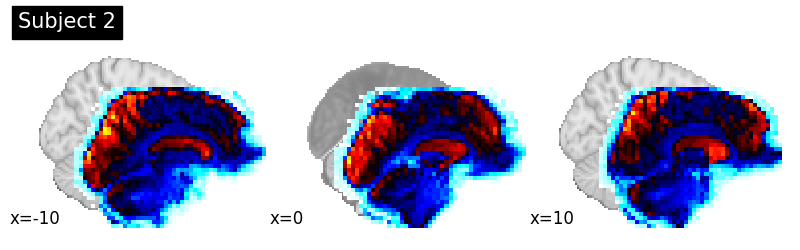

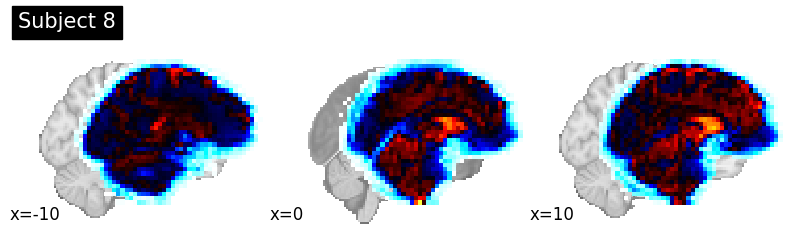

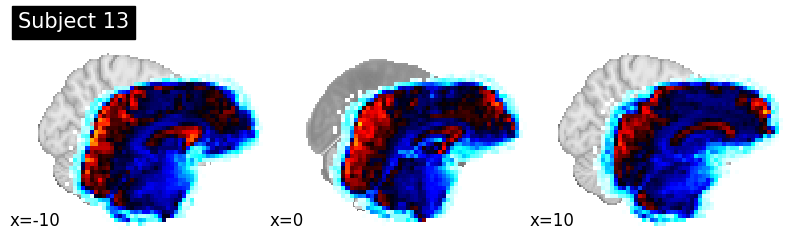

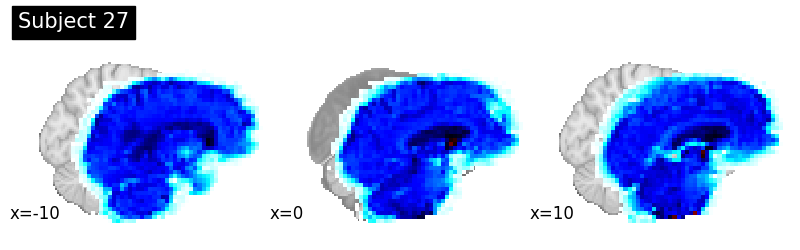

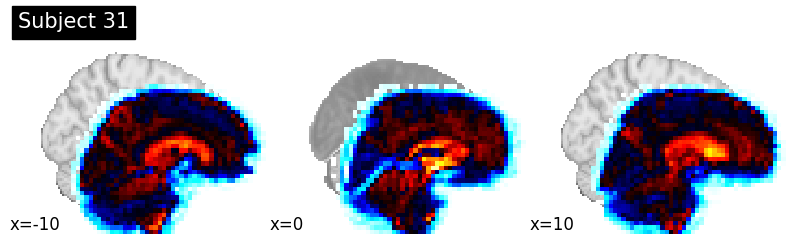

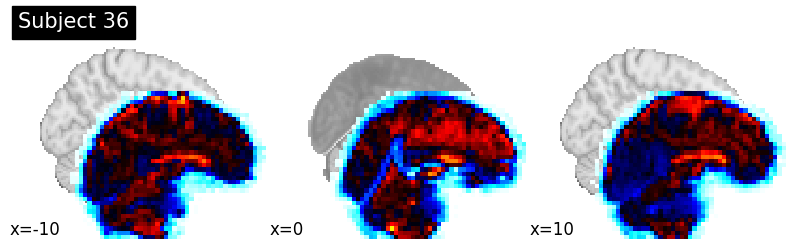

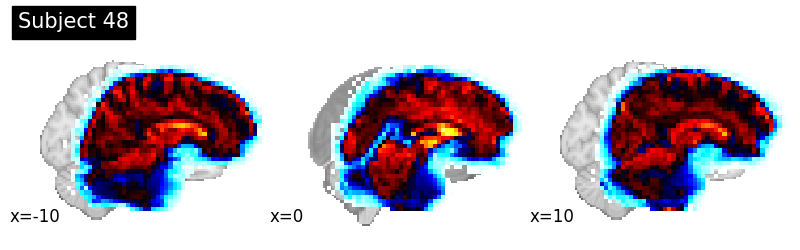

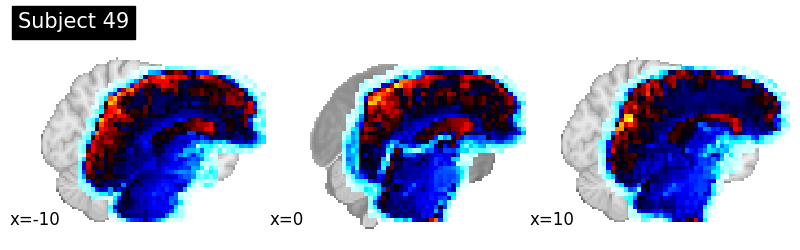

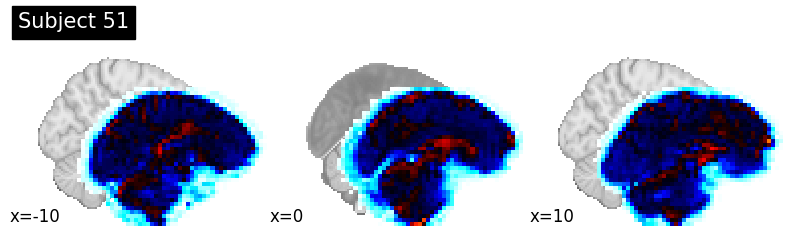

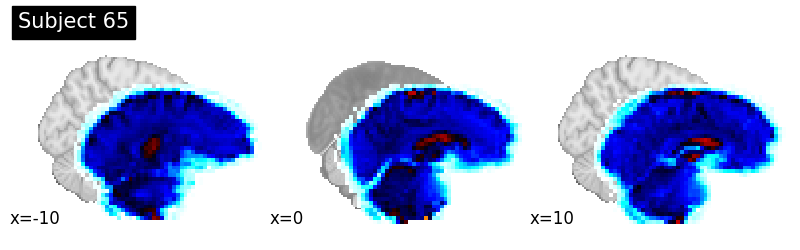

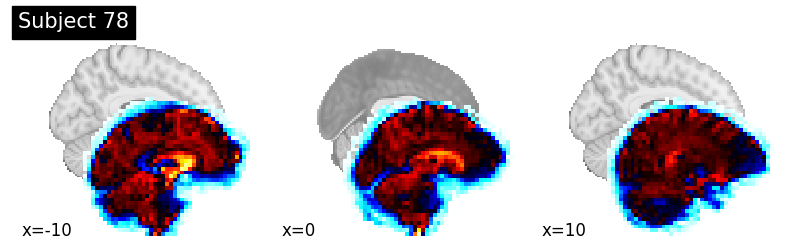

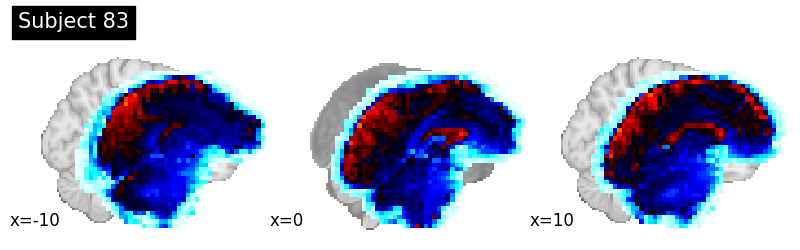

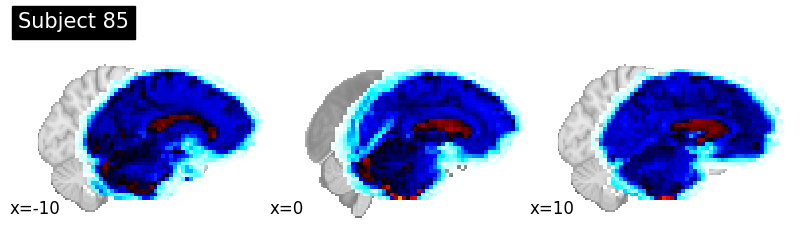

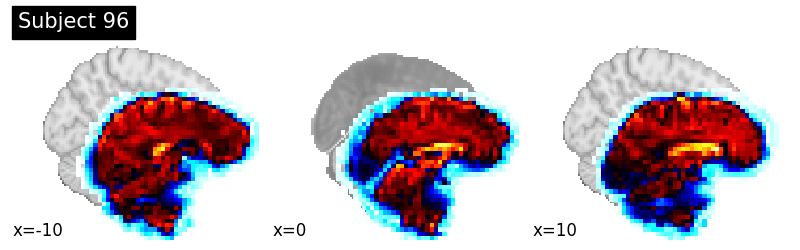

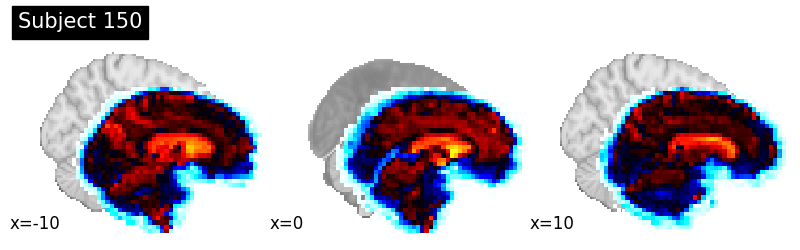

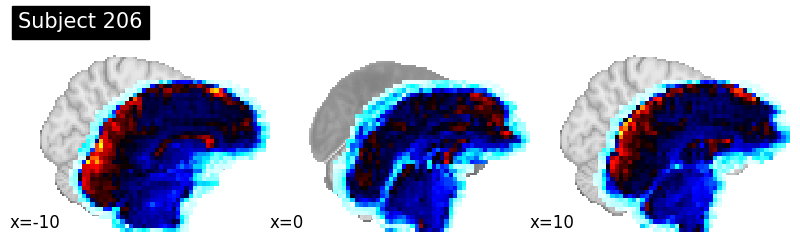

In [6]:
from nilearn.plotting import plot_stat_map, show
#visualising bold mask
for subject in subjects:
  str_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_bold.nii"
  for img in image.iter_img(str_img):
    plot_stat_map(img, threshold = 3, display_mode = "x", cut_coords = [-10,0,10], colorbar = False, title = "Subject " + str(subject))
    show()
#
    break


**Checking parcellation of anat data**

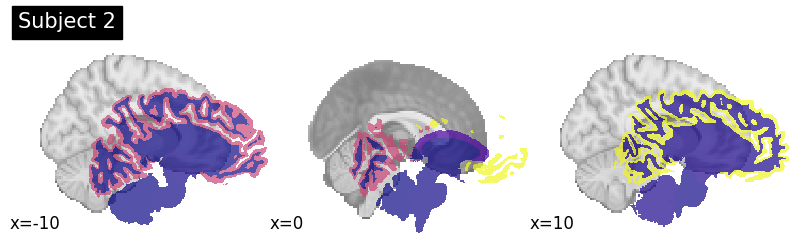

(256, 256, 256)


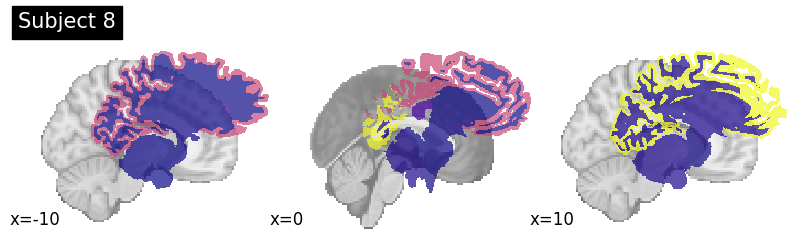

(256, 256, 256)


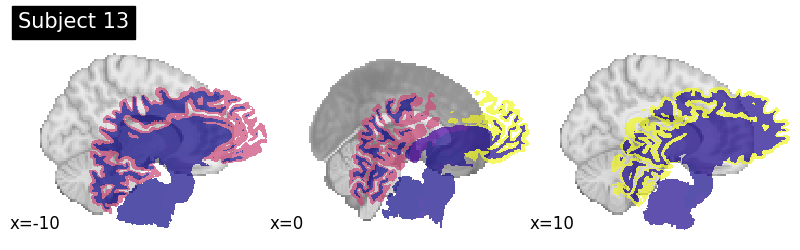

(256, 256, 256)


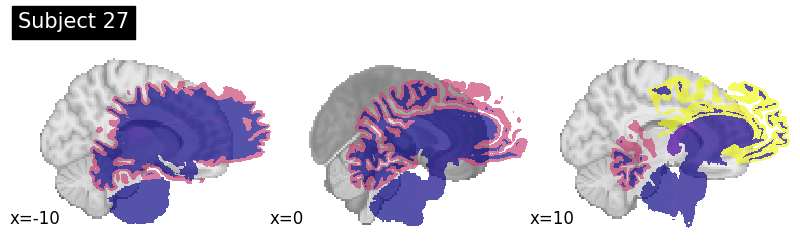

(256, 256, 256)


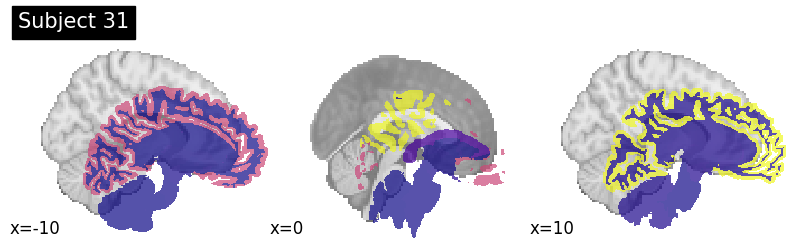

(256, 256, 256)


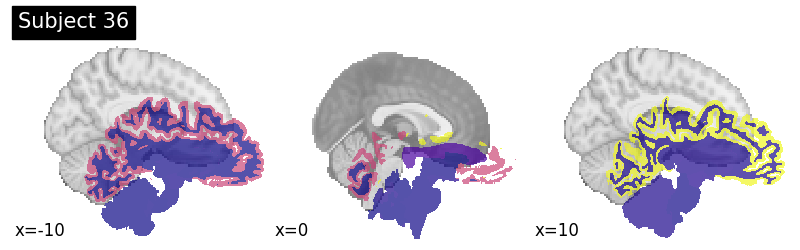

(256, 256, 256)


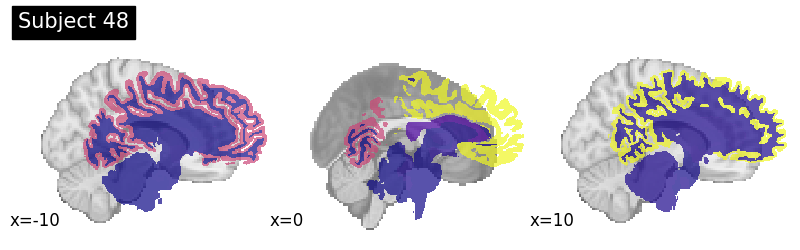

(256, 256, 256)


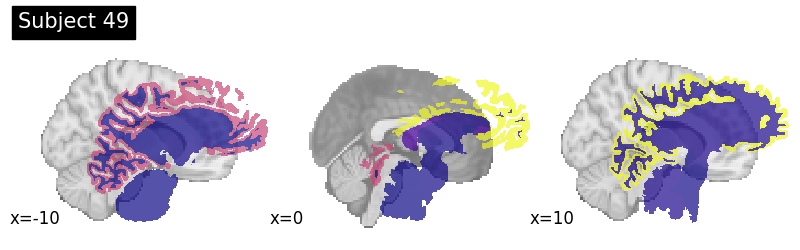

(256, 256, 256)


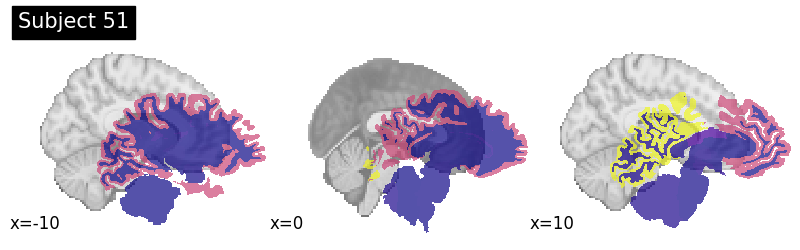

(256, 256, 256)


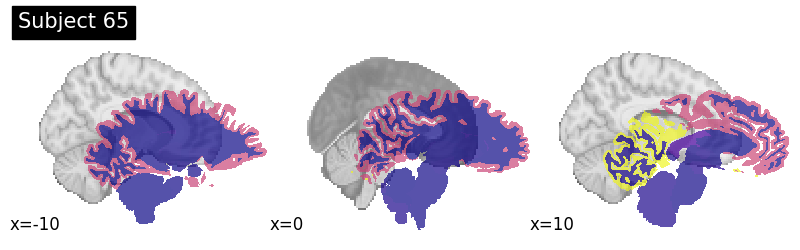

(256, 256, 256)


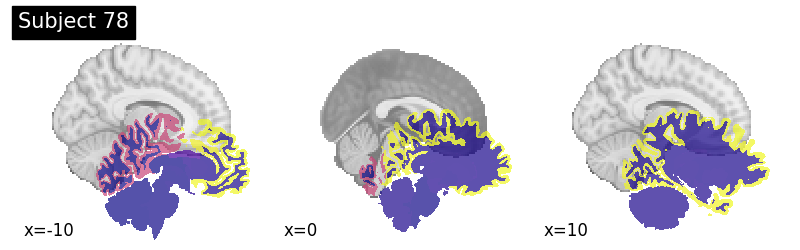

(256, 256, 256)


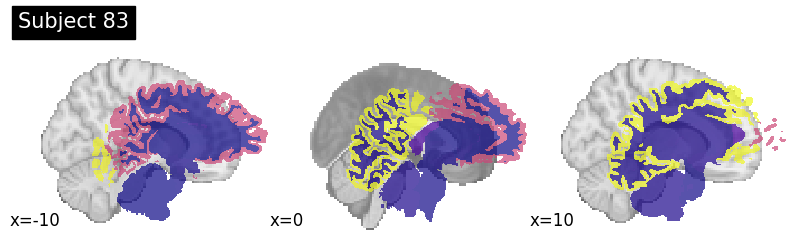

(256, 256, 256)


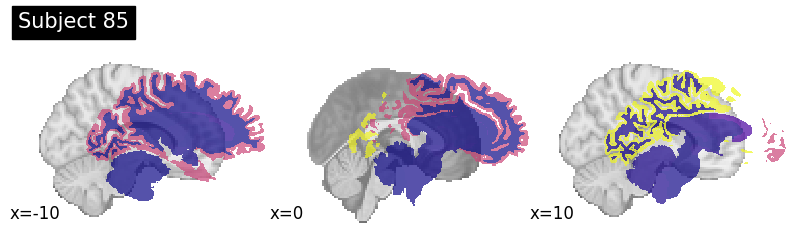

(256, 256, 256)


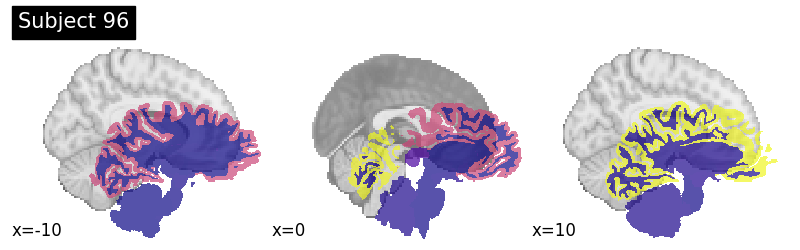

(256, 256, 256)


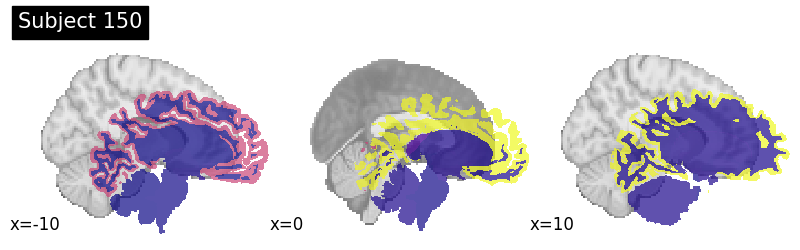

(256, 256, 256)


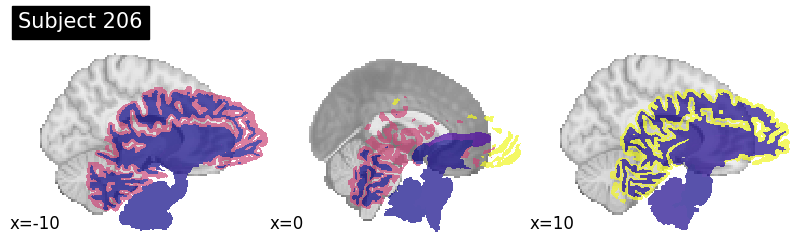

(256, 256, 256)


In [7]:
# Load and display the parcellation file; not as useful
for subject in subjects:
  parc_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"
  plotting.plot_roi(parc_img, display_mode="x", cut_coords=[-10, 0, 10], cmap = "plasma", title="Subject " + str(subject))
  plotting.show()
  nl.EXPAND_PATH_WILDCARDS = False
  anat_obj = image.load_img(parc_img)
  print(anat_obj.shape)

**getting names of our parecellated regions**

In [8]:
#getting parc label names for time series
import numpy as np
import json

for subject in subjects:
  with open("/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_dktlabel.json", "r") as f:
    labels_file = json.load(f)

  # regions actually covered in our parc file
  unique_vals = np.unique(image.get_data("/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"))

  # filter names based on what is in parc file
  lab_names = [entry["name"] for entry in labels_file if entry["voxel_value"] in unique_vals]
  lab_inds = [entry["label"] for entry in labels_file if entry["voxel_value"] in unique_vals]#string entries

  print(len(lab_names))
  print(len(lab_inds))

  #print((unique_vals))
  #label_inds.remove("0")
  print(len(unique_vals))

# with open("sub_2_dktlabel.json", "r") as f:
#     labels2_file = json.load(f)

# # regions actually covered in our parc file
# unique_vals2 = np.unique(image.get_data(parc_img2))

# # filter names based on what is in parc file
# lab2_names = [entry["name"] for entry in labels2_file] # if entry["voxel_value"] in unique_vals
# lab2_inds = [entry["label"] for entry in labels2_file if entry["voxel_value"] in unique_vals2]#string entries

# print(len(lab2_names))
# print(len(lab2_inds))

# #print((unique_vals))
# #label_inds.remove("0")
# print(len(unique_vals2))


110
110
110
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104


**generating our time series data from our anat and func files**

In [9]:
# extracting time series with niftilabelsmasker
from nilearn.input_data import NiftiLabelsMasker
import matplotlib.pyplot as plt

for subject in subjects:
  parc_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"
  masker = NiftiLabelsMasker(labels_img=parc_img, background_label= 0, standardize="zscore_sample", title = "Subject " + str(subject))
  masker.fit()
  masker.generate_report()

  #time series
  bold_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_bold.nii"
  fmri_obj = image.load_img(bold_img)
  time_series = masker.fit_transform(bold_img)
  print(time_series.shape)

#

# masker2 = NiftiLabelsMasker(labels_img=anat_obj2, background_label= 0, standardize="zscore_sample")
# masker2.fit()
# masker2.generate_report()

# #time series
# time_series2 = masker2.fit_transform(fmri_obj2)
# print(time_series2.shape)

# #-------------------

# masker7 = NiftiLabelsMasker(labels_img=anat_obj7, background_label= 0, standardize="zscore_sample")
# masker7.fit()
# masker7.generate_report()

# #time series
# time_series7 = masker7.fit_transform(fmri_obj7)
# print(time_series7.shape)

<ipython-input-9-0a8b40a5a13c>:9: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


(164, 109)


<ipython-input-9-0a8b40a5a13c>:9: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


<ipython-input-9-0a8b40a5a13c>:9: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


...

(164, 101)


<ipython-input-9-0a8b40a5a13c>:9: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


<ipython-input-9-0a8b40a5a13c>:9: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


**visualizing our time series from above**

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


(164, 109)


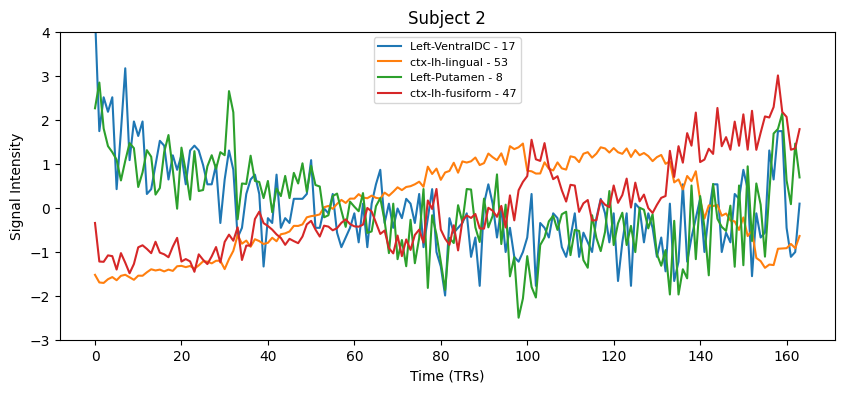

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


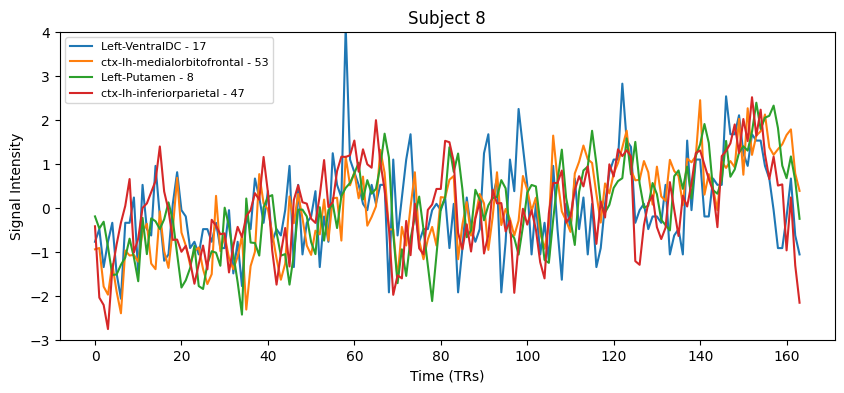

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


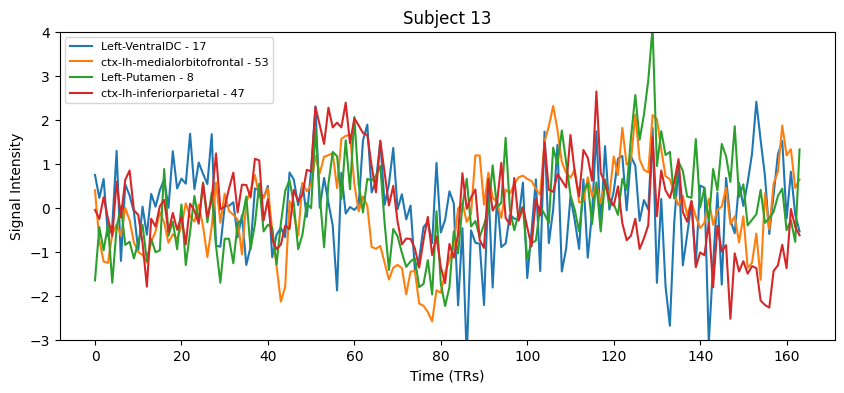

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


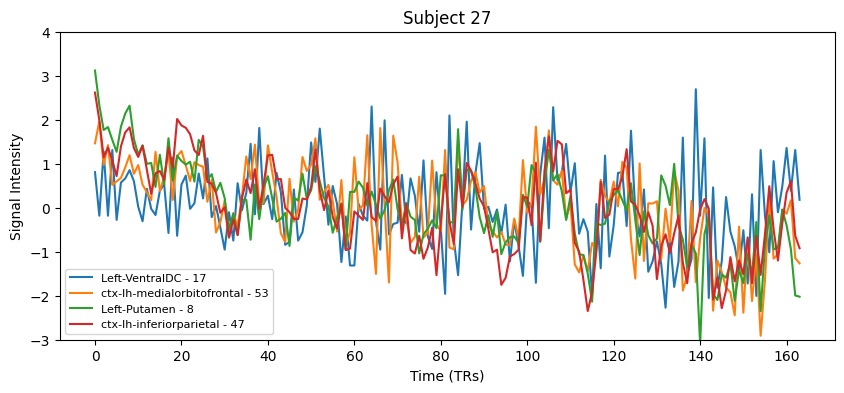

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


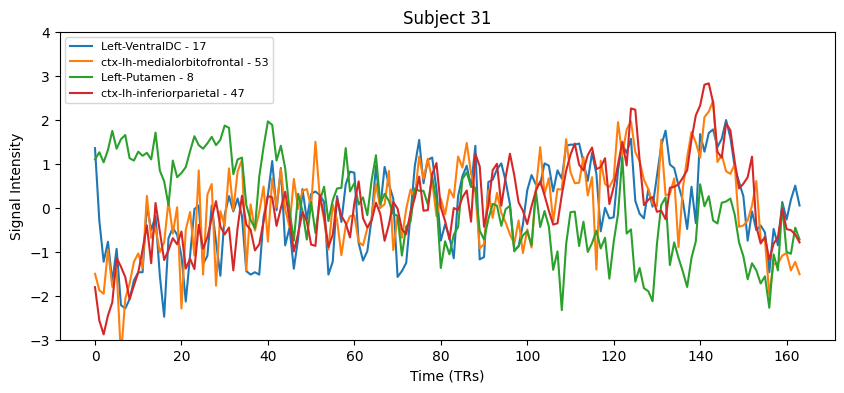

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(85), np.int32(62)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


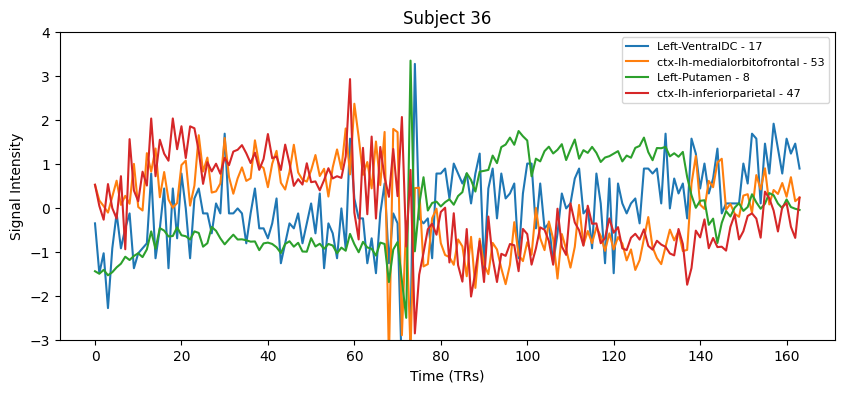

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


(164, 103)


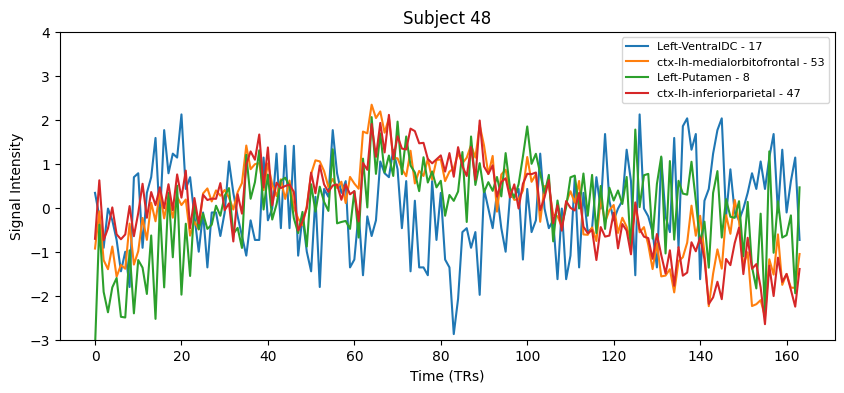

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


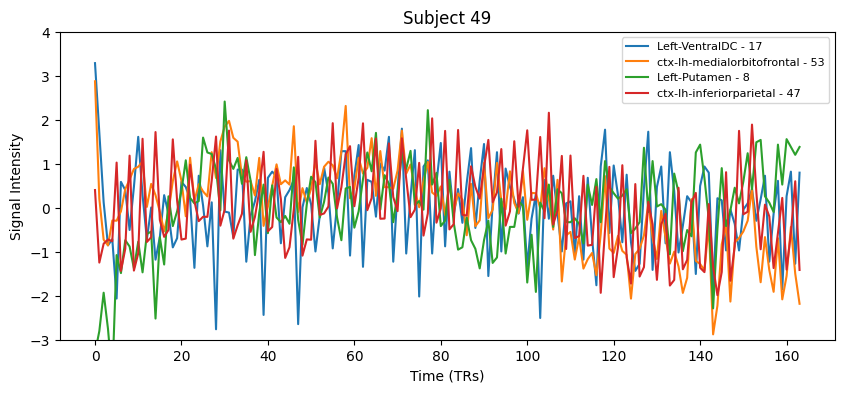

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


(164, 103)


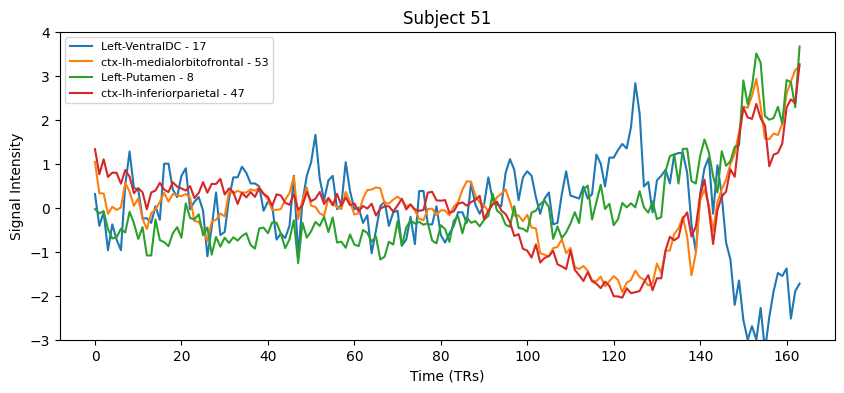

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


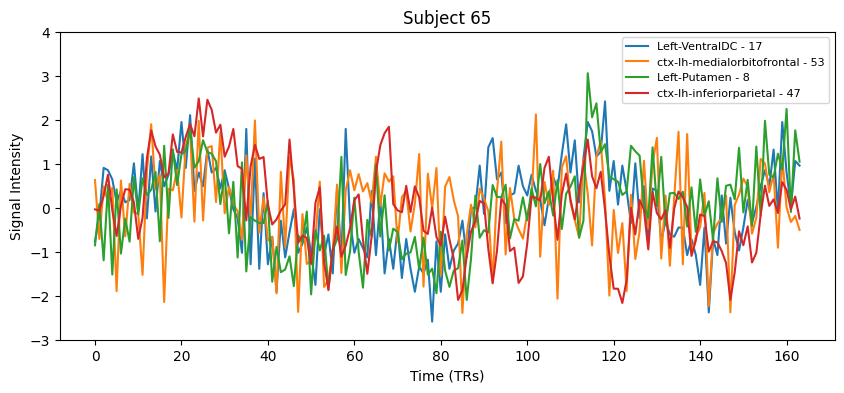

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


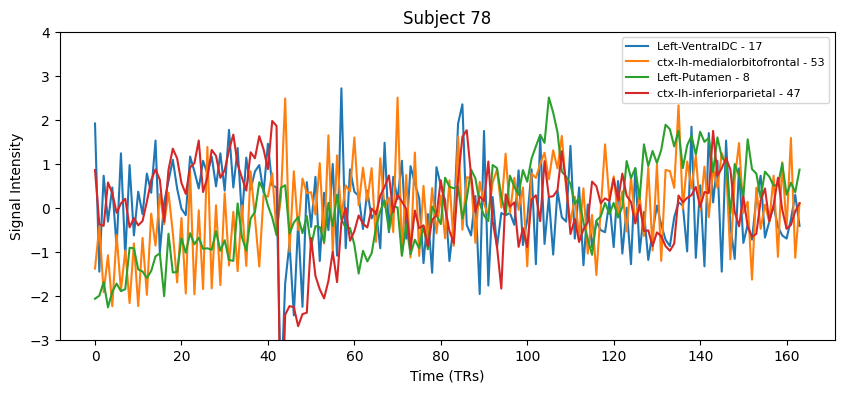

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


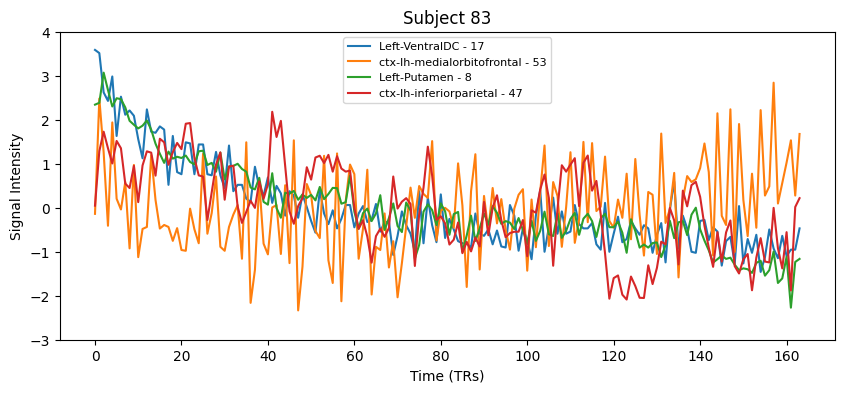

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


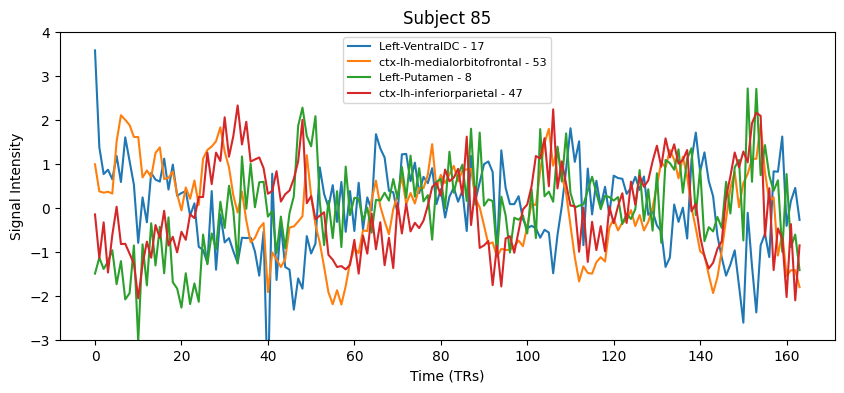

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(85), np.int32(62)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


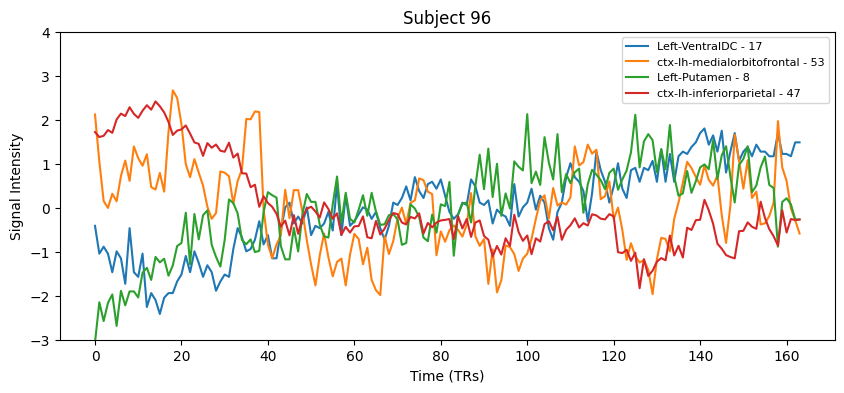

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


(164, 102)


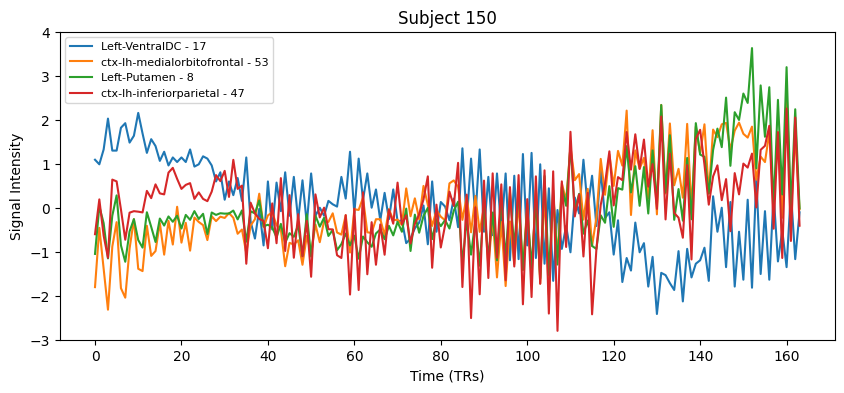

<ipython-input-10-ed117c63d3db>:24: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


(164, 101)


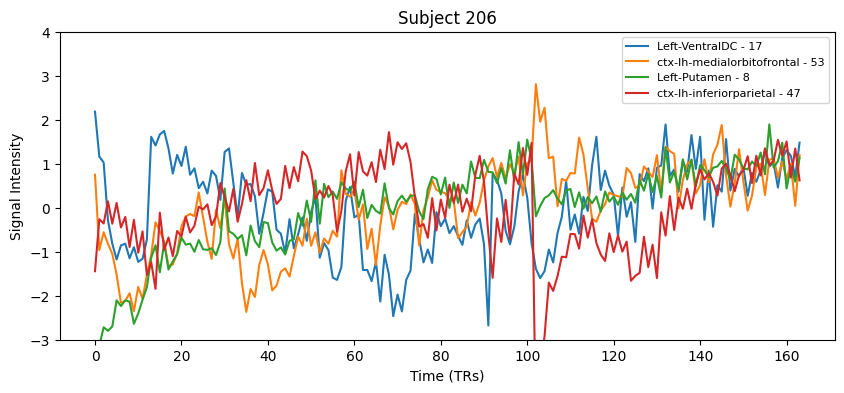

In [10]:
#visualize fmri time series based on regions
np.random.seed(2004)

#num_regions = 5
selected_regions = np.array([17, 53, 8 , 47])

#np.random.choice(time_series2.shape[1], num_regions, replace=False)

for subject in subjects:
  # parc labels
    with open("/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_dktlabel.json", "r") as f:
      labels_file = json.load(f)

    # regions actually covered in our parc file
    unique_vals = np.unique(image.get_data("/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"))

    # filter names based on what is in parc file
    lab_names = [entry["name"] for entry in labels_file if entry["voxel_value"] in unique_vals]

  # time series stuff
    parc_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"
    masker = NiftiLabelsMasker(labels_img=parc_img, background_label= 0, standardize="zscore_sample", title = "Subject " + str(subject))
    masker.fit()
    masker.generate_report()

    bold_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_bold.nii"
    fmri_obj = image.load_img(bold_img)
    time_series = masker.fit_transform(bold_img)
    print(time_series.shape)


  #print(selected_regions2)
    plt.figure(figsize=(10, 4))
    for region in selected_regions:
        plt.plot(time_series[:, region], label= (lab_names[region])+" - " + str(region)) #indexing based on og labels file; going up to 5 to match other

    plt.xlabel('Time (TRs)')
    plt.ylabel('Signal Intensity')
    plt.title('Subject ' + str(subject))
    plt.legend(prop={'size': 8})
    plt.ylim(-3, 4)
    plt.show()


# #print(selected_regions2)
# plt.figure(figsize=(10, 4))
# for region in selected_regions:
#     plt.plot(time_series2[:5, region], label= (lab2_names[region])+" - " + str(region)) #indexing based on og labels file; going up to 5 to match other

# plt.xlabel('Time (TRs)')
# plt.ylabel('Signal Intensity')
# plt.title('Extracted Time Series; Subject 2 (Normal)')
# plt.legend(prop={'size': 8})
# plt.ylim(-3, 4)
# plt.show()

# #-------------------------

# #num_regions = 5
# #selected_regions7 = np.random.choice(time_series7.shape[1], num_regions, replace=False)

# #print(selected_regions7)
# plt.figure(figsize=(10, 4))
# for region in selected_regions:
#     plt.plot(time_series7[:, region], label= (lab7_names[region])+" - " + str(region)) #indexing based on og labels file

# plt.xlabel('Time (TRs)')
# plt.ylabel('Signal Intensity')
# plt.title('Extracted Time Series; Subject 7 (Abnormal)')
# plt.legend(prop={'size': 8})
# plt.ylim(-3, 4)
# plt.show()

**creating corr matrix for subject 2**

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


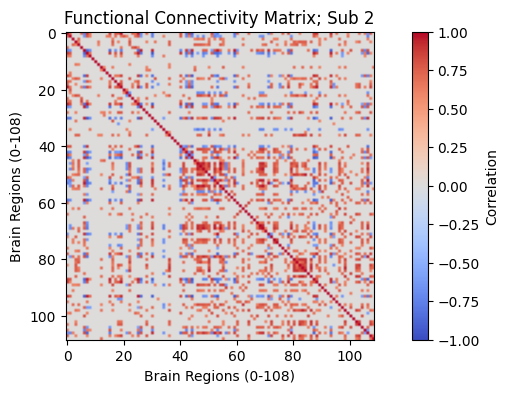

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


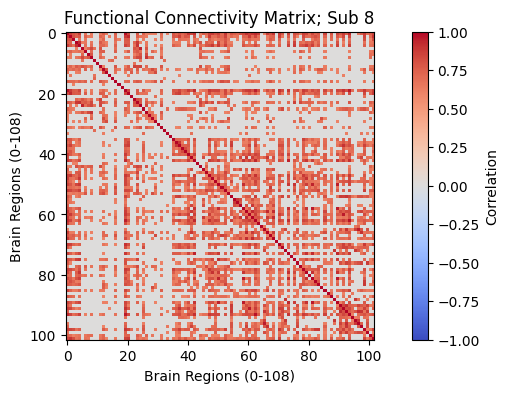

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


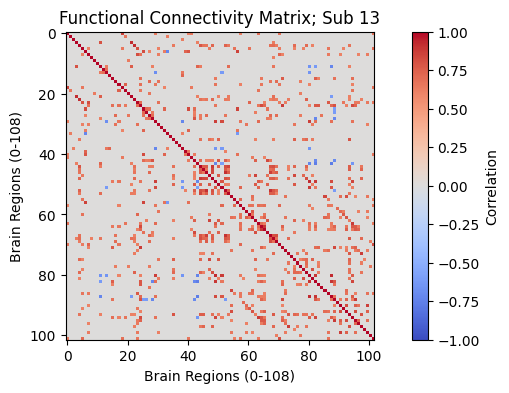

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


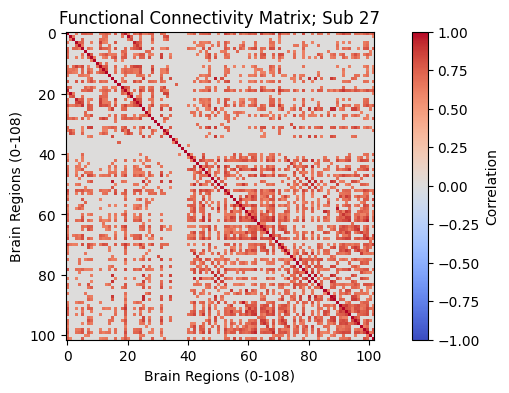

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


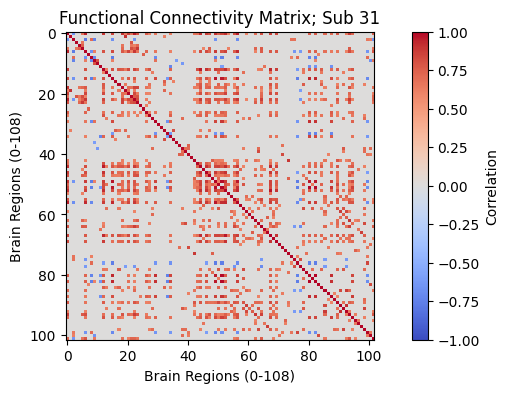

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(85), np.int32(62)}. Label image only contains 102 labels (including background).
  warnings.warn(


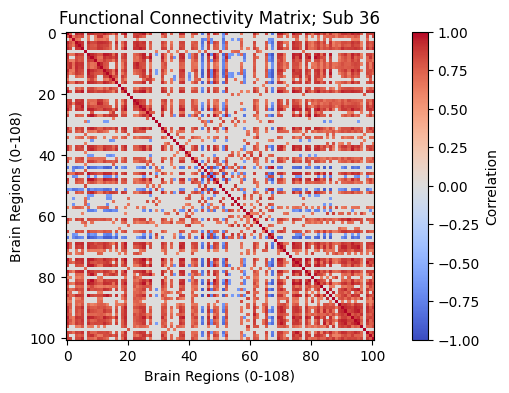

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


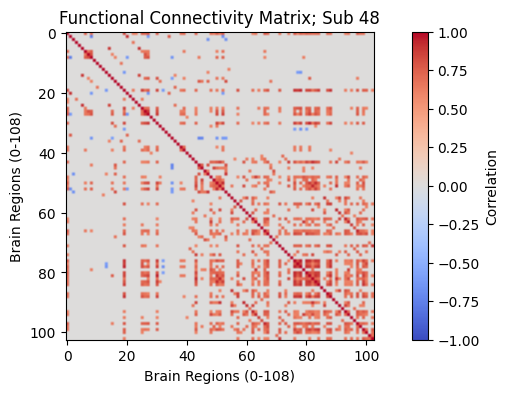

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


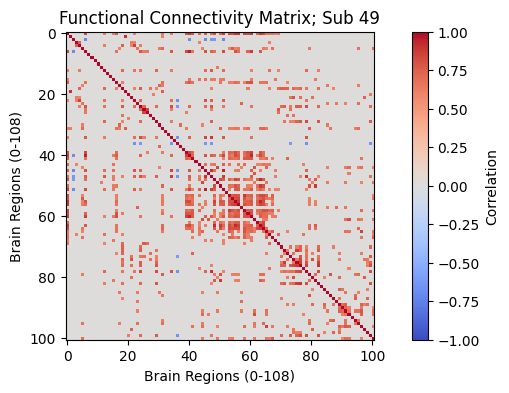

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()


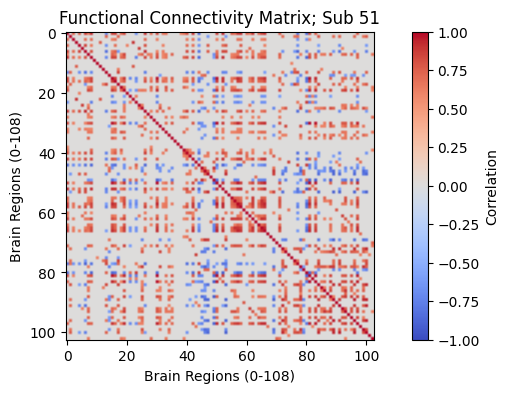

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


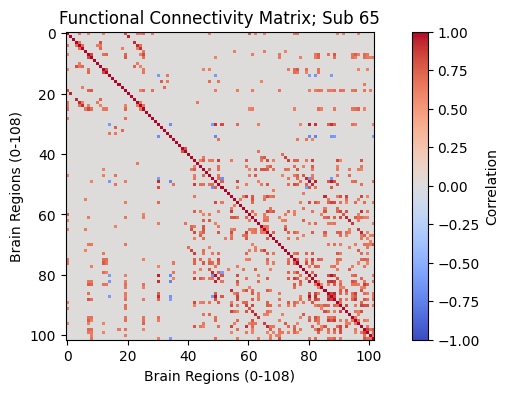

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


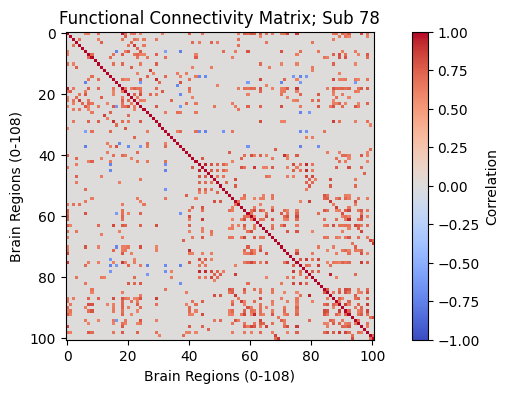

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 103 labels (including background).
  warnings.warn(


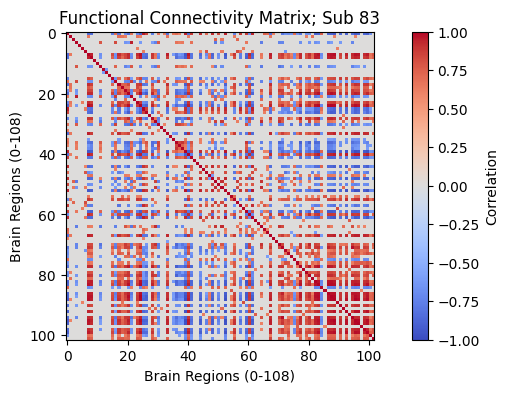

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


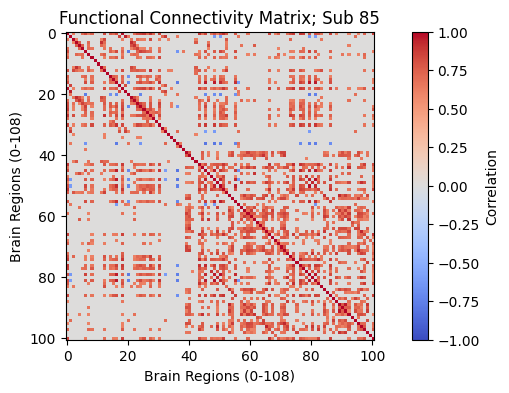

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(85), np.int32(62)}. Label image only contains 102 labels (including background).
  warnings.warn(


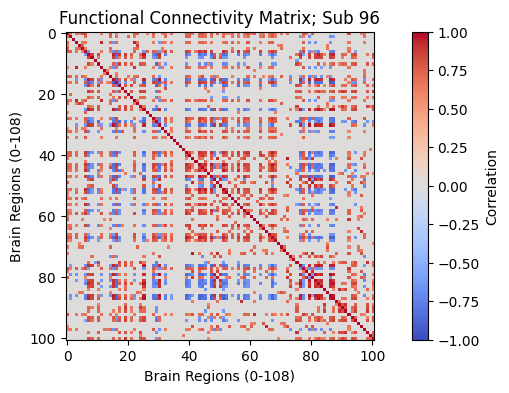

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62)}. Label image only contains 103 labels (including background).
  warnings.warn(


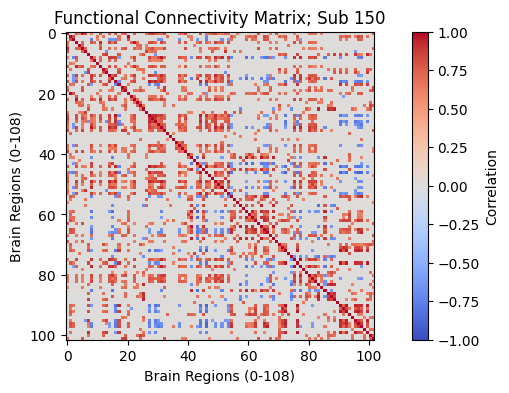

<ipython-input-11-dc6a3793e4e7>:8: UserWarning: No image provided to fit in NiftiLabelsMasker. Plotting ROIs of label image on the MNI152Template for reporting.
  masker.generate_report()
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(62), np.int32(30)}. Label image only contains 102 labels (including background).
  warnings.warn(


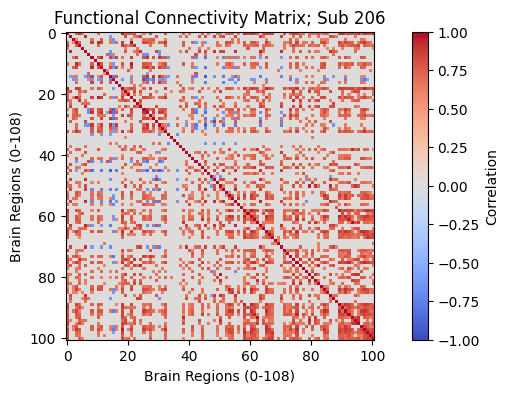

In [11]:
#finally cor matrix
# Compute the correlation matrix
for subject in subjects:
  # time series
  parc_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_parc.nii"
  masker = NiftiLabelsMasker(labels_img=parc_img, background_label= 0, standardize="zscore_sample", title = "Subject " + str(subject))
  masker.fit()
  masker.generate_report()

  bold_img = "/content/drive/MyDrive/OASIS Preprop/OASIS_preprocessed/sub-"+str(subject)+"/sub" + str(subject) + "_bold.nii"
  fmri_obj = image.load_img(bold_img)
  time_series = masker.fit_transform(bold_img)

  # matrix
  corr_matrix = np.corrcoef(time_series.T)  # Transpose so regions are along rows
  corr_matrix[np.abs(corr_matrix) < 0.6] = 0 # thresholding
  # Plot the connectivity matrix
  plt.figure(figsize=(10, 4))
  plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
  plt.colorbar(label="Correlation")
  plt.title("Functional Connectivity Matrix; Sub " + str(subject))
  plt.xlabel("Brain Regions (0-108)")
  plt.ylabel("Brain Regions (0-108)")
  plt.show()

# there are 109 identified regions

# #-----------------------------

# corr_matrix7 = np.corrcoef(time_series7.T)  # Transpose so regions are along rows
# corr_matrix7[np.abs(corr_matrix7) < 0.6] = 0 # thresholding
# # Plot the connectivity matrix
# plt.figure(figsize=(10, 4))
# plt.imshow(corr_matrix7, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label="Correlation")
# plt.title("Functional Connectivity Matrix; Sub 7 (Abnormal)")
# plt.xlabel("Brain Regions (0-108)")
# plt.ylabel("Brain Regions (0-108)")
# plt.show()

Modeling area

get 2 more abnormal uploaded, and 1 between